# Handling Missing Value & Outliers
**Kecerdasan Buatan**

Nama: Mikhael Josua Roganda     
NIM: 42324023

# Praktikum: Missing Value

In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


Menghitung jumlah data yang hilang (NaN) di setiap kolom untuk memahami kualitas dataset.

In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

Menghitung persentase data yang hilang untuk mengevaluasi apakah perlu dihapus atau diisi ulang.

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

df.dropna digunakan untuk menghapus baris atau kolom yang memiliki missing values.

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


thresh = 5 berarti hanya baris yang memiliki minimal 5 nilai valid yang dipertahankan. Contohnya baris indeks 2 hilang karena pada indeks tersebut nilai yang tidak berisi NaN kurang dari 5.

In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


Dengan menambahkan subset 'Age', maka hanya baris yang berisi NaN di kolom Age yang dihapus.

In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


Menghapus kolom Blood Type dengan df.drop()

In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


.fillna() digunakan untuk mengisi nilai yang kosong (missing values). Imputasi nilai bisa menggunakan beberapa metode statistik seperti mean, median, mode.

Missing value pada kolom Age akan diisi dengan nilai rata-rata atau mean, Shoe Chart dengan median, dan Fav Fruit dengan mode.

In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


Selain itu, missing value bisa juga diisi dengan back fill dan forward fill. Back fill untuk mengisi nilai kosong di "Shoe Chart" dengan nilai dari bawahnya atau setelahnya. Forward fill untuk mengisi nilai kosong di "Fav Fruit" dengan nilai sebelumnya.

In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


# Praktikum: Outliers

In [ ]:
import pandas as pd
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


Mendeteksi outliers secara visual dengan menggunakan boxplot dari seaborn dan menghapus outliers dengan menggunakan Interquartile Range.

Outliers berada di luar titik whiskers pada boxplot.

<Axes: ylabel='Height'>

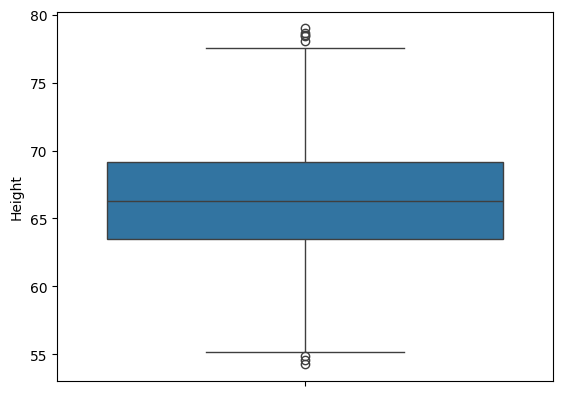

In [ ]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

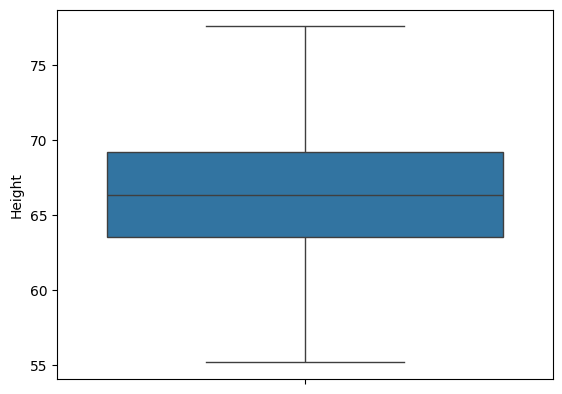

In [ ]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
                  & (df2['Height'] <= upper_bound)]

sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

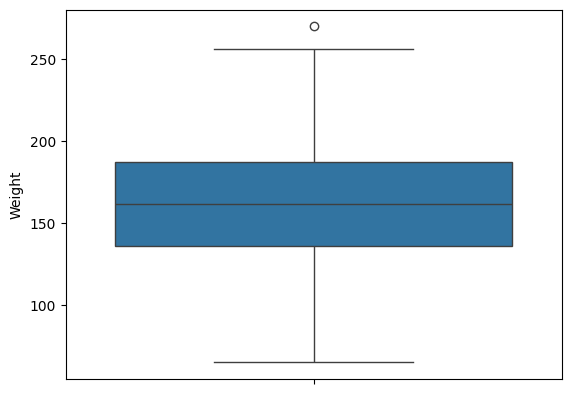

In [ ]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

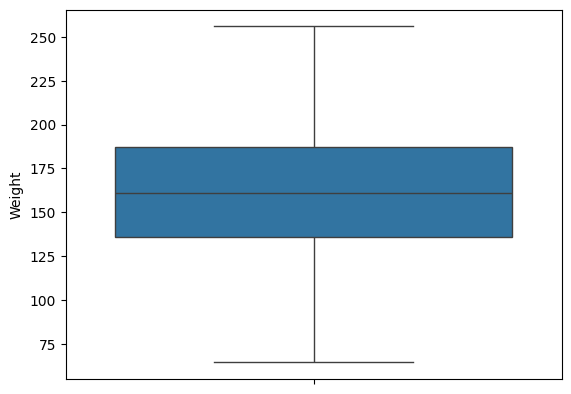

In [ ]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
                  & (df2['Weight'] <= upper_bound)]

sns.boxplot(clean_data['Weight'])

Mendeteksi outliers dengan visualisasi dari matplotlib.

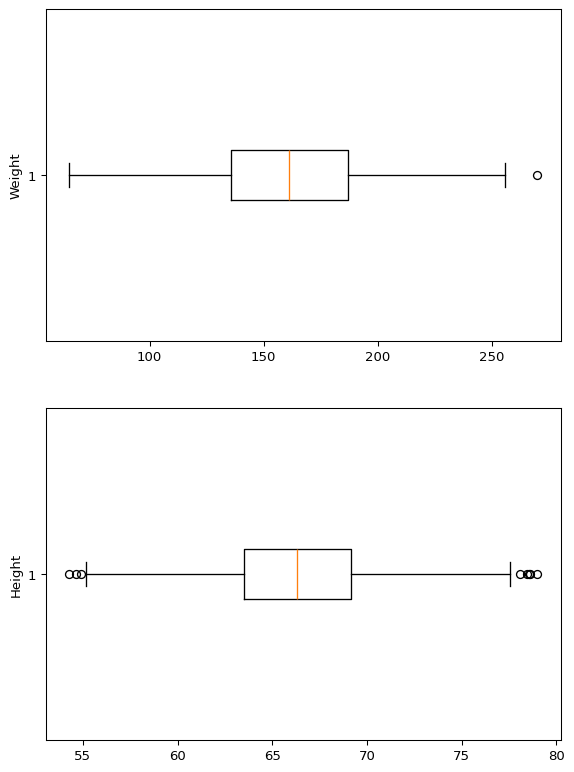

In [ ]:
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis, yaitu "Weight" dan "Height".
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

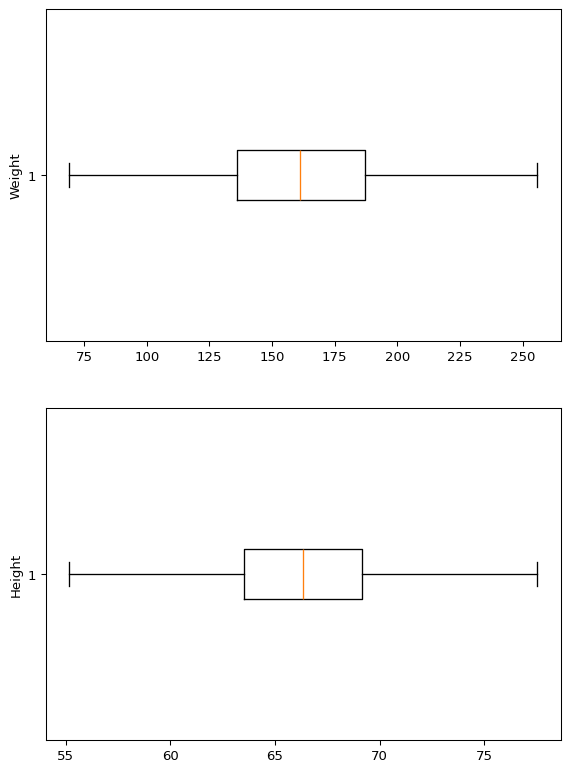

In [ ]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])

# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

Melakukan scaling (normalisasi) data numerik menggunakan MinMaxScaler.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns  # Ambil kolom numerik
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns  # Ambil kolom non-numerik

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [ ]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)

# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)

final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


# Tugas: Handling Missing Value pada Titanic-Dataset.csv

In [18]:
df_titanic = pd.read_csv("Titanic-Dataset.csv")
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Mengecek jumlah missing value di setiap kolom.

In [19]:
df_titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Mengecek persentase missing value untuk menentukan strategi penanganan.

In [20]:
percent_missing_titanic = 100 * df_titanic.isnull().mean()
percent_missing_titanic[percent_missing_titanic > 0]

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

**Strategi penanganan missing value:**
- Kolom `Cabin` memiliki missing value sekitar 77% (sangat tinggi), sehingga kolom ini di-*drop* karena tidak layak diimputasi.
- Kolom `Age` memiliki missing value sekitar 19.9%, diisi dengan **median** karena distribusi umur cenderung tidak simetris (skewed), sehingga median lebih representatif dibanding mean.
- Kolom `Embarked` hanya memiliki 2 baris missing (0.2%), diisi dengan **modus** karena bertipe kategorikal.

In [21]:
df_titanic_clean = df_titanic.drop(columns=["Cabin"])
df_titanic_clean["Age"] = df_titanic_clean["Age"].fillna(df_titanic_clean["Age"].median())
df_titanic_clean["Embarked"] = df_titanic_clean["Embarked"].fillna(df_titanic_clean["Embarked"].mode().iloc[0])
df_titanic_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Verifikasi bahwa semua missing value sudah teratasi.

In [23]:
df_titanic_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Tugas: Handling Outliers pada diabetes.csv

In [ ]:
df_diabetes = pd.read_csv("diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Kolom yang dipilih untuk deteksi outlier: **Glucose, BloodPressure, BMI**.

Ketiga kolom ini dipilih karena secara medis nilainya tidak mungkin 0, sehingga nilai ekstrem (termasuk nilai 0) dapat terdeteksi sebagai outlier menggunakan boxplot dan IQR.

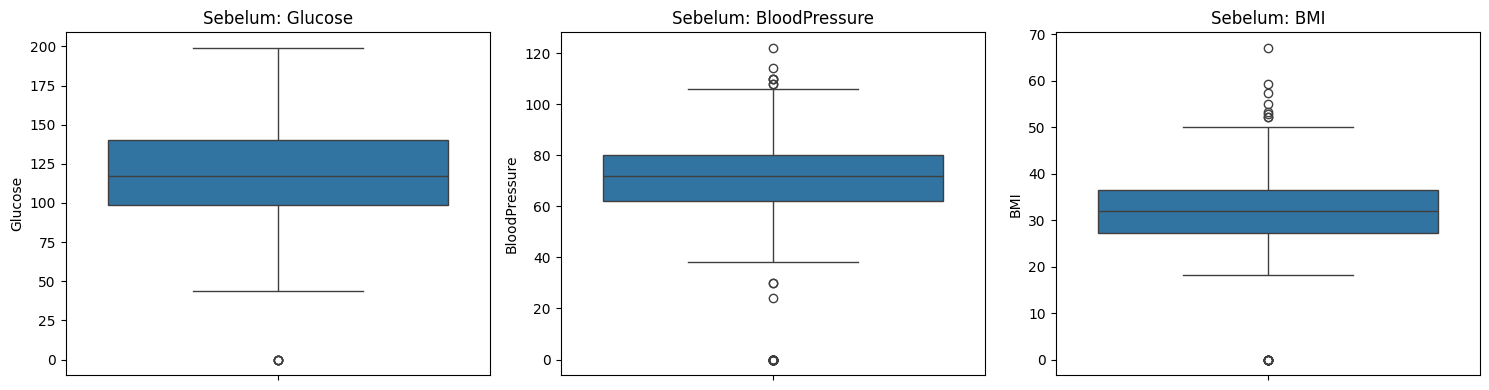

In [ ]:
cols = ["Glucose", "BloodPressure", "BMI"]

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols):
    sns.boxplot(y=df_diabetes[col], ax=axs[i])
    axs[i].set_title(f"Sebelum: {col}")
plt.tight_layout()
plt.show()

Mendeteksi dan menghapus outlier menggunakan metode **Interquartile Range (IQR)**, dilakukan secara berurutan (sequential) untuk masing-masing kolom.

In [ ]:
def remove_outliers_iqr(data, columns):
    data_cleaned = data.copy()
    for col in columns:
        q1, q3 = np.percentile(data_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        data_cleaned = data_cleaned[(data_cleaned[col] >= lower_bound) & (data_cleaned[col] <= upper_bound)]
    return data_cleaned

diabetes_clean = remove_outliers_iqr(df_diabetes, cols)
print("Jumlah baris sebelum:", len(df_diabetes))
print("Jumlah baris sesudah:", len(diabetes_clean))

Jumlah baris sebelum: 768
Jumlah baris sesudah: 709


Visualisasi boxplot setelah outlier dihapus.

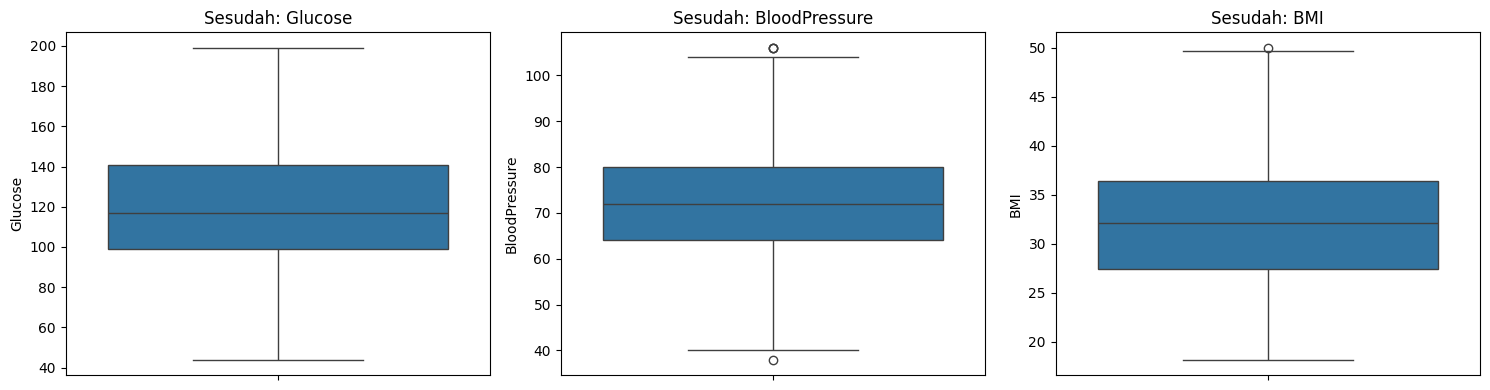

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols):
    sns.boxplot(y=diabetes_clean[col], ax=axs[i])
    axs[i].set_title(f"Sesudah: {col}")
plt.tight_layout()
plt.show()